In [ ]:
# Core
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Statistics & Modeling
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from statsmodels.tsa.seasonal import seasonal_decompose

# Style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 120

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving delhi-weather-aqi-2025.csv to delhi-weather-aqi-2025.csv


In [ ]:
# Load dataset
df = pd.read_csv("delhi-weather-aqi-2025.csv")

# Clean column names
df.columns = df.columns.str.strip().str.lower()

# Convert correct date column
df['date'] = pd.to_datetime(df['date_ist'], dayfirst=True)

# Sort by date
df = df.sort_values('date')

# Create time features
df['month'] = df['date'].dt.month
df['day_of_year'] = df['date'].dt.dayofyear
df['week'] = df['date'].dt.isocalendar().week

df.head()

,date_ist,time_ist,location,lat,lon,temp_c,humidity,pressure_mb,windspeed_kph,condition_text,description,aqi_index,pm2_5,pm10,co,no2,date,month,day_of_year,week
0,01/01/2025,0:00,Anand Vihar,28.6469,77.3160,8.1,100,995.4,2.9,Mainly clear,WMO Code 1,197,185.8,188.6,1907,56.7,2025-01-01,1,1,1
92,01/01/2025,20:00,Okhla Phase III,28.5273,77.2618,11.2,91,991.8,4.5,Clear sky,WMO Code 0,202,167.6,170.4,1673,68.6,2025-01-01,1,1,1
93,01/01/2025,21:00,Okhla Phase III,28.5273,77.2618,11.1,91,991.9,5.8,Clear sky,WMO Code 0,200,168.6,171.8,1642,65.4,2025-01-01,1,1,1
94,01/01/2025,22:00,Okhla Phase III,28.5273,77.2618,10.8,92,991.6,6.6,Clear sky,WMO Code 0,199,170.9,174.2,1586,59.7,2025-01-01,1,1,1
95,01/01/2025,23:00,Okhla Phase III,28.5273,77.2618,10.4,93,991.3,7.1,Mainly clear,WMO Code 1,198,170.4,173.2,1519,52.6,2025-01-01,1,1,1


In [ ]:
print("Start Date:", df['date'].min())
print("End Date:", df['date'].max())
print("Total Records:", len(df))

Start Date: 2025-01-01 00:00:00
End Date: 2025-12-31 00:00:00
Total Records: 52560


In [ ]:
df.isnull().sum()

,0
date_ist,0
time_ist,0
location,0
lat,0
lon,0
temp_c,0
humidity,0
pressure_mb,0
windspeed_kph,0
condition_text,0


In [ ]:
df.fillna(method='ffill', inplace=True)

/tmp/ipython-input-1214/3970806690.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


In [ ]:
df['temp_c'].describe()

print("Skewness:", df['temp_c'].skew())
print("Kurtosis:", df['temp_c'].kurt())

Skewness: -0.29819609119725904
Kurtosis: -0.5879874832409784


In [ ]:
monthly_stats = df.groupby('month')['temp_c'].agg(['mean','min','max','std'])
monthly_stats

,mean,min,max,std
month,,,,
1,13.810797,5.7,26.5,4.151014
2,18.552257,9.3,30.8,4.434913
3,23.984005,11.1,38.5,5.572903
4,31.107106,16.8,42.5,5.437062
5,31.728584,21.6,43.0,4.757035
6,31.981296,23.5,43.8,4.394423
7,29.581429,24.8,37.5,2.650916
8,28.778898,24.1,34.7,2.181690
9,29.817315,23.9,38.5,3.478281


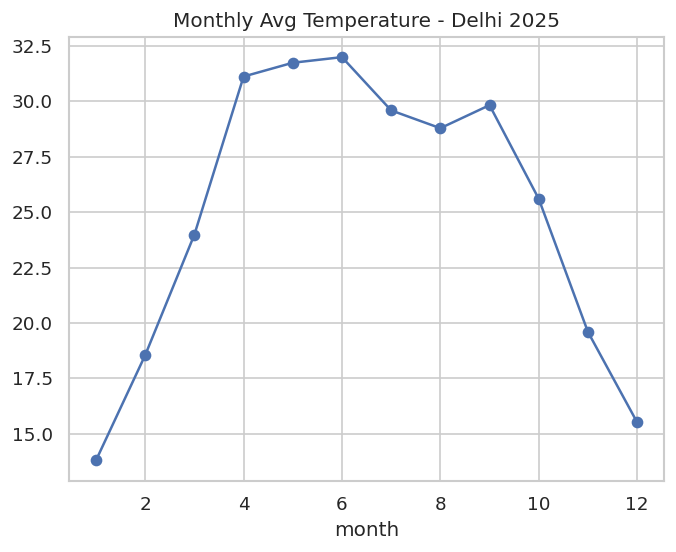

In [ ]:
monthly_stats['mean'].plot(marker='o')
plt.title("Monthly Avg Temperature - Delhi 2025")
plt.show()

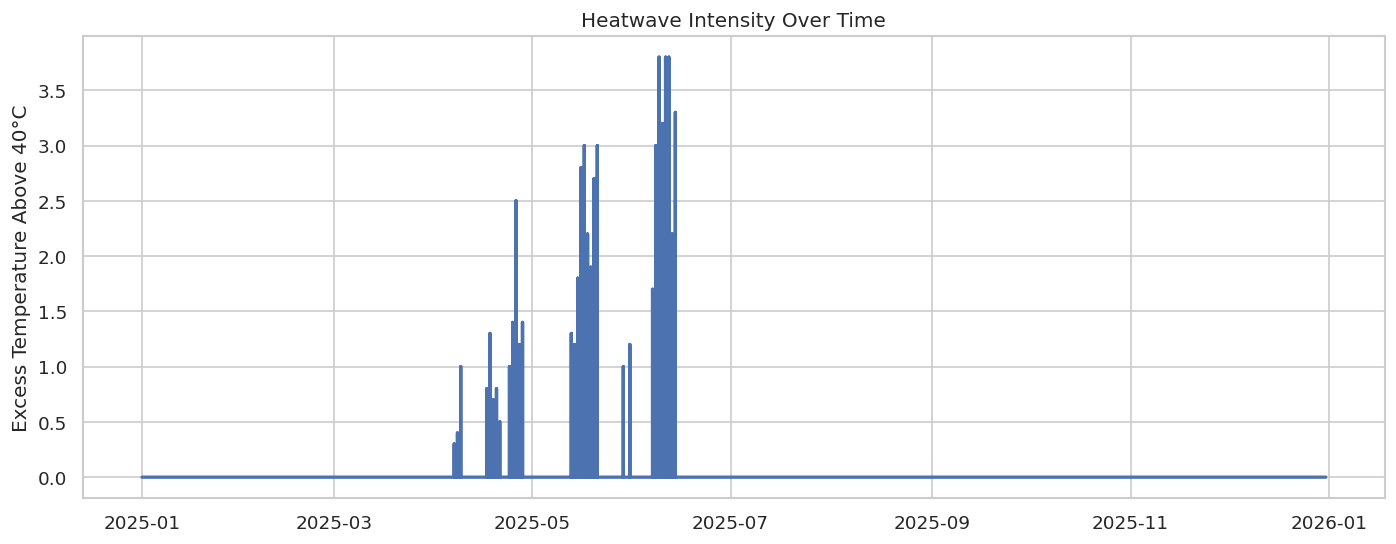

In [ ]:
df['heat_intensity'] = np.where(df['temp_c'] > 40,
                                df['temp_c'] - 40,
                                0)

plt.figure(figsize=(14,5))
plt.plot(df['date'], df['heat_intensity'], linewidth=2)
plt.title("Heatwave Intensity Over Time")
plt.ylabel("Excess Temperature Above 40°C")
plt.show()

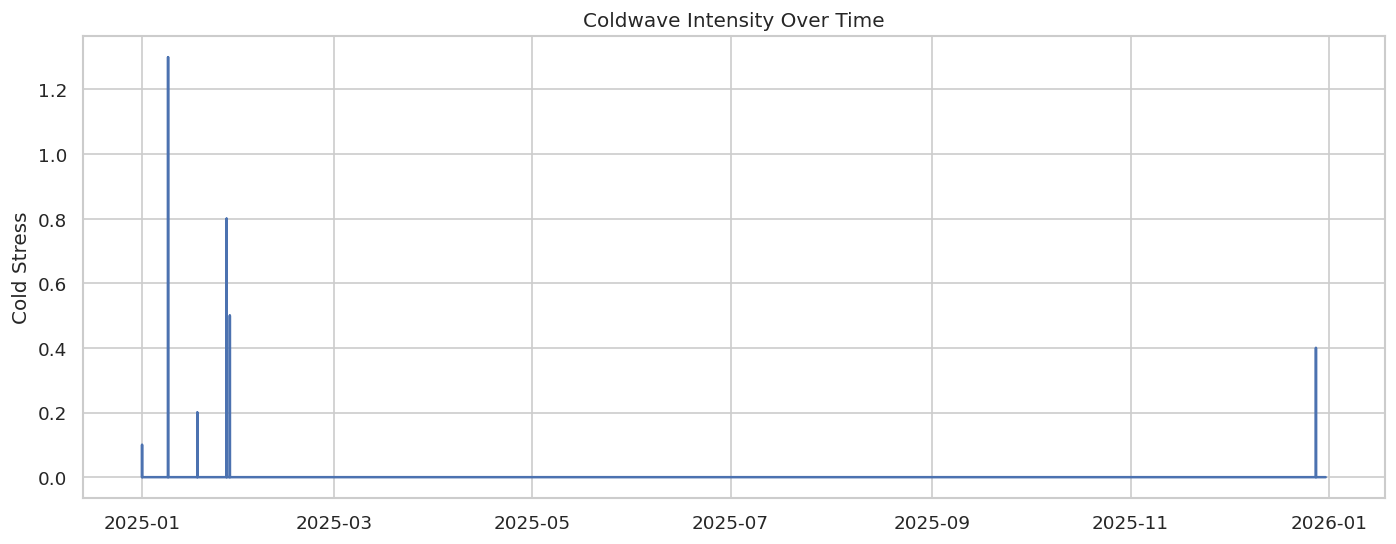

In [ ]:
df['cold_intensity'] = np.where(df['temp_c'] < 7,
                                7 - df['temp_c'],
                                0)

plt.figure(figsize=(14,5))
plt.plot(df['date'], df['cold_intensity'])
plt.title("Coldwave Intensity Over Time")
plt.ylabel("Cold Stress")
plt.show()

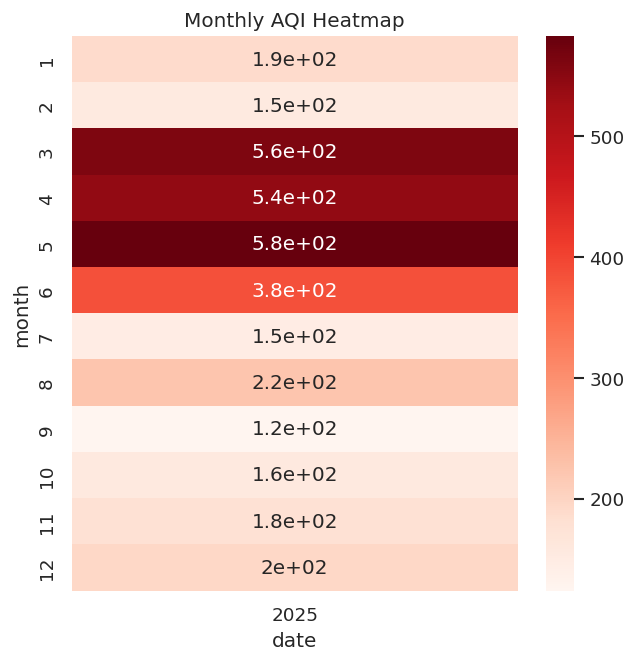

In [ ]:
aqi_pivot = df.pivot_table(values='aqi_index',
                           index='month',
                           columns=df['date'].dt.year)

plt.figure(figsize=(6,6))
sns.heatmap(aqi_pivot, annot=True, cmap='Reds')
plt.title("Monthly AQI Heatmap")
plt.show()

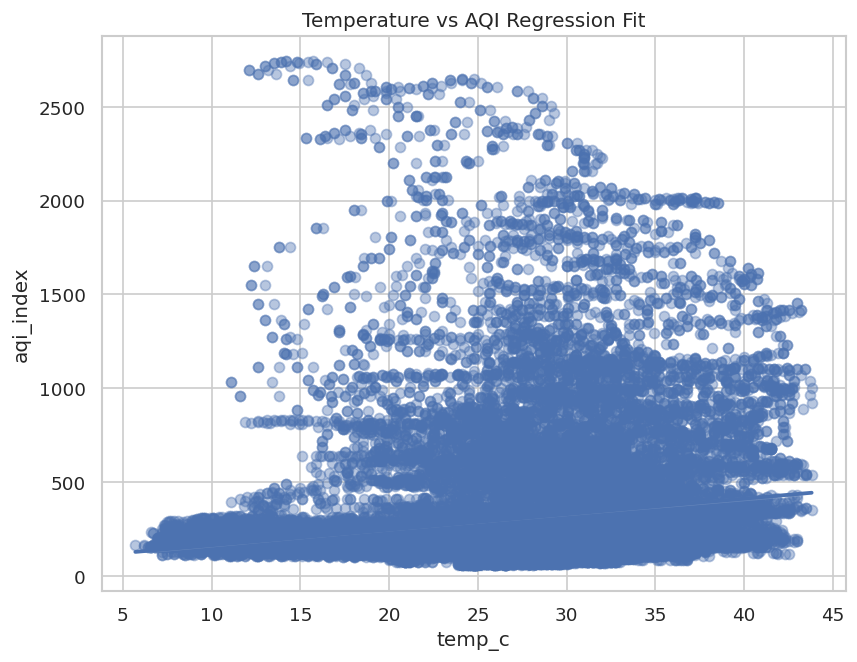

In [ ]:
plt.figure(figsize=(8,6))
sns.regplot(x='temp_c',
            y='aqi_index',
            data=df,
            scatter_kws={'alpha':0.4})
plt.title("Temperature vs AQI Regression Fit")
plt.show()

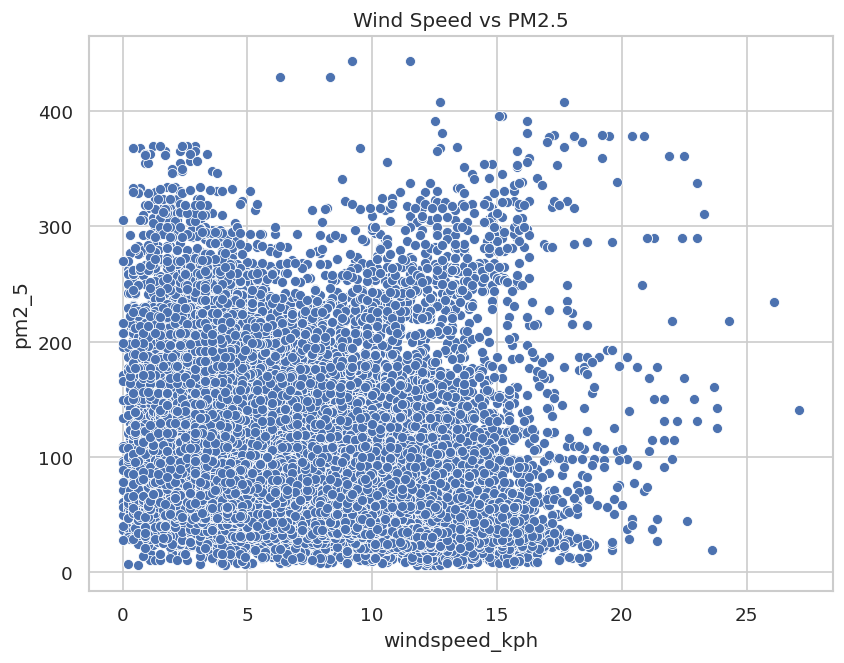

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='windspeed_kph',
                y='pm2_5',
                data=df)
plt.title("Wind Speed vs PM2.5")
plt.show()

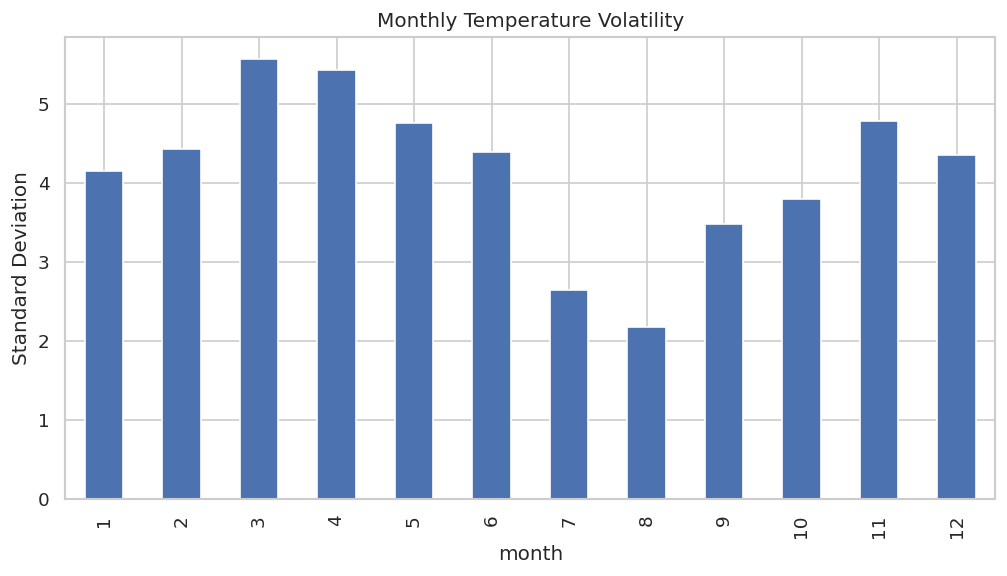

In [ ]:
monthly_volatility = df.groupby('month')['temp_c'].std()

plt.figure(figsize=(10,5))
monthly_volatility.plot(kind='bar')
plt.title("Monthly Temperature Volatility")
plt.ylabel("Standard Deviation")
plt.show()

In [ ]:
from scipy import stats

df['temp_z'] = stats.zscore(df['temp_c'])
anomalies = df[abs(df['temp_z']) > 2]

anomalies[['date','temp_c']].head()

,date,temp_c
0,2025-01-01,8.1
96,2025-01-01,7.4
97,2025-01-01,7.3
98,2025-01-01,7.0
100,2025-01-01,6.9


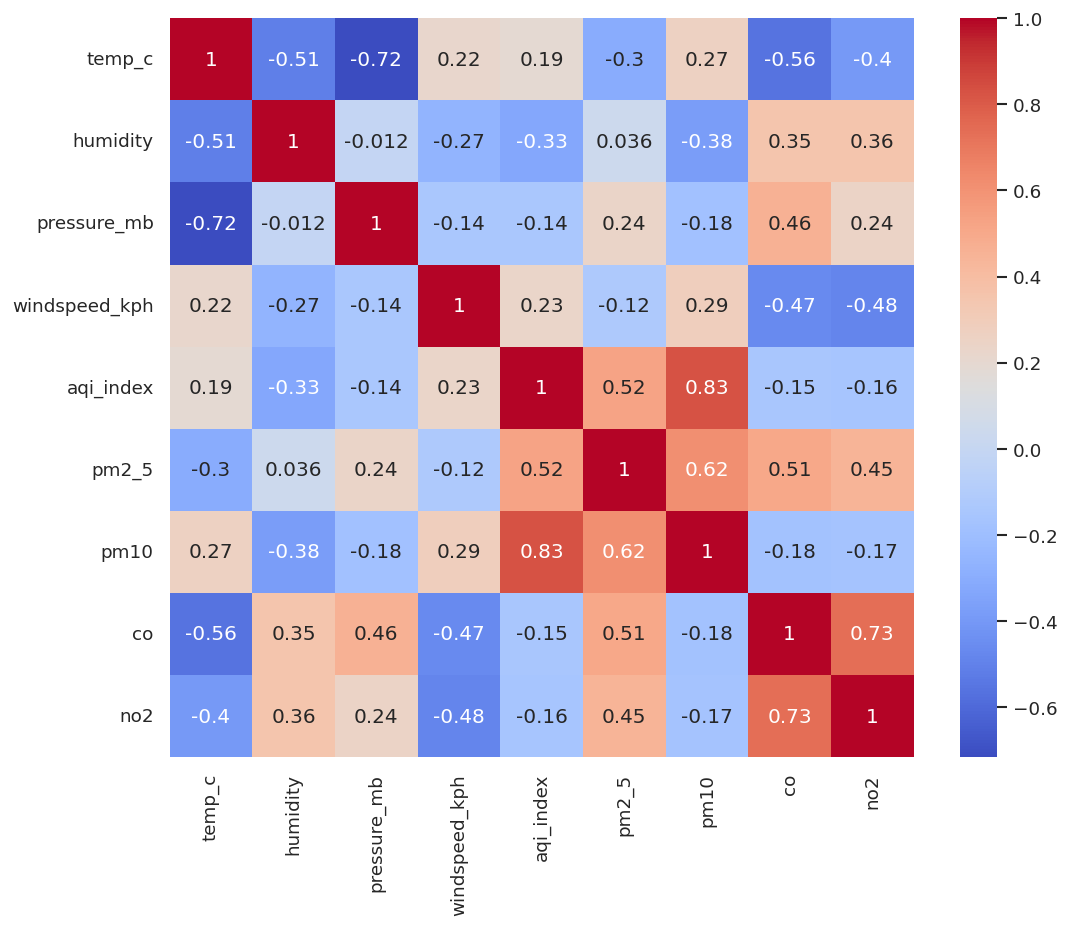

In [ ]:
corr = df[['temp_c','humidity','pressure_mb',
           'windspeed_kph','aqi_index',
           'pm2_5','pm10','co','no2']].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

In [ ]:
df['risk_score'] = (
    df['temp_c']*0.3 +
    df['aqi_index']*0.4 +
    df['pm2_5']*0.3
)

df['risk_score'].describe()

,risk_score
count,52560.000000
mean,149.315736
std,140.964177
min,33.040000
25%,84.070000
50%,100.845000
75%,144.500000
max,1186.170000


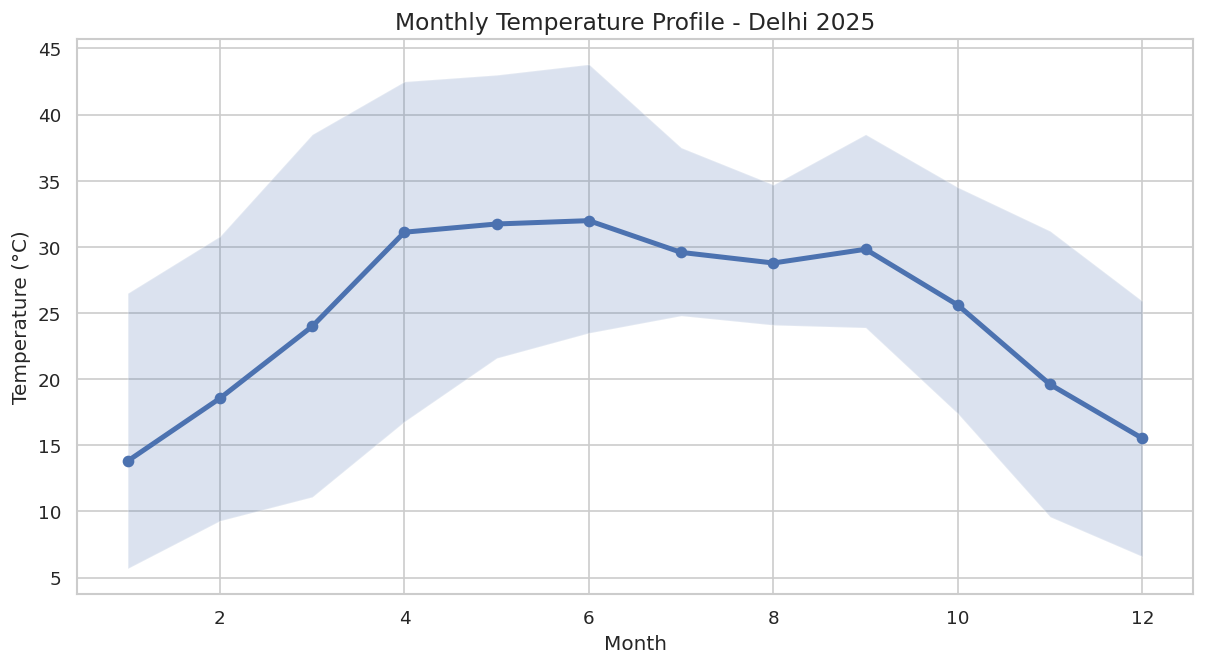

In [ ]:
plt.figure(figsize=(12,6))
monthly_stats['mean'].plot(marker='o', linewidth=3)
plt.fill_between(monthly_stats.index,
                 monthly_stats['min'],
                 monthly_stats['max'],
                 alpha=0.2)

plt.title("Monthly Temperature Profile - Delhi 2025", fontsize=14)
plt.xlabel("Month")
plt.ylabel("Temperature (°C)")
plt.grid(True)
plt.show()

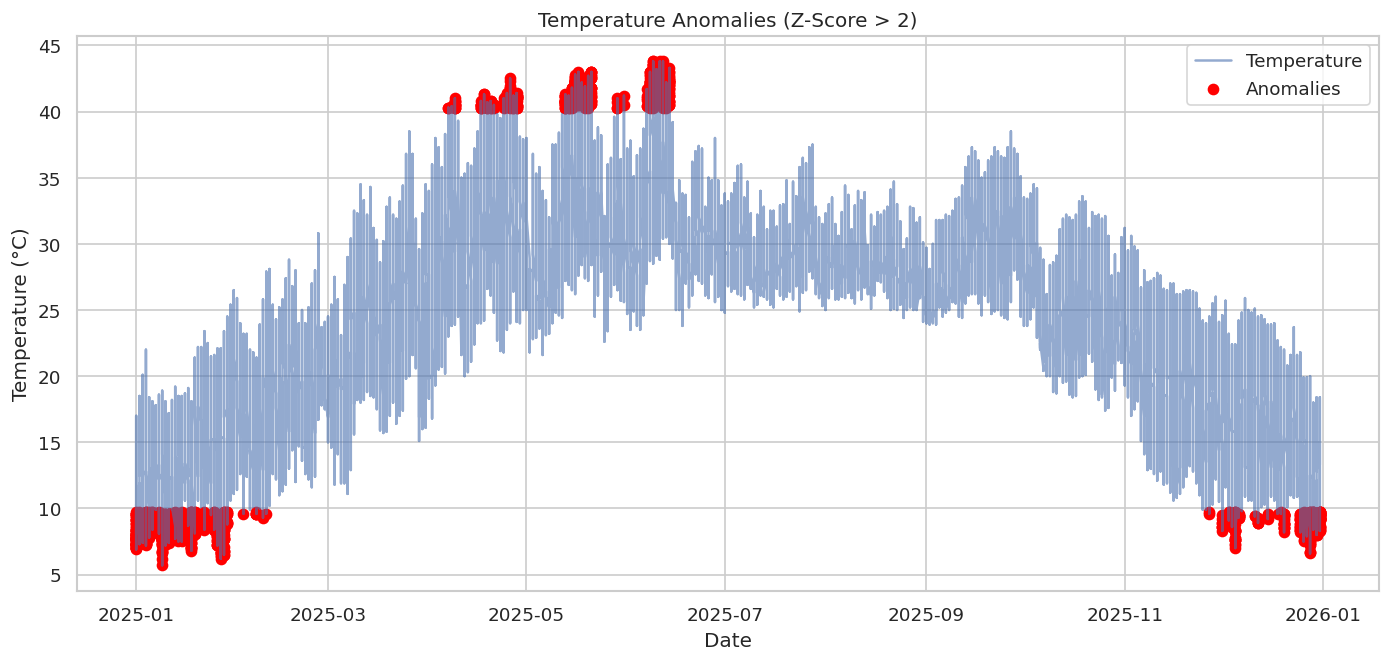

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Assuming df is your DataFrame and has 'temp_c' column

# Calculate Z-scores for temperature
df['z_score'] = stats.zscore(df['temp_c'])

# Filter anomalies where Z-score > 2 or < -2
anomalies = df[df['z_score'].abs() > 2]

# Now plot
plt.figure(figsize=(14,6))
plt.plot(df['date'], df['temp_c'], alpha=0.6, label='Temperature')
plt.scatter(anomalies['date'],
            anomalies['temp_c'],
            color='red',
            label='Anomalies')

plt.title("Temperature Anomalies (Z-Score > 2)")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.show()

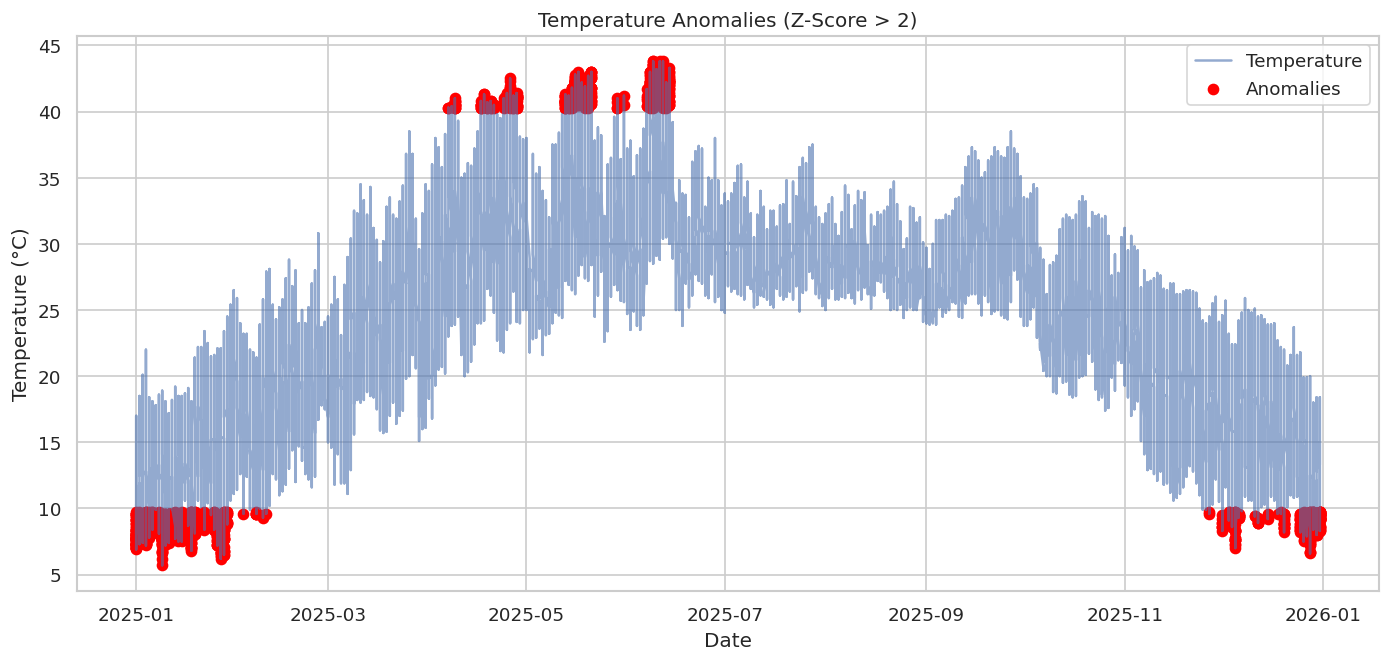

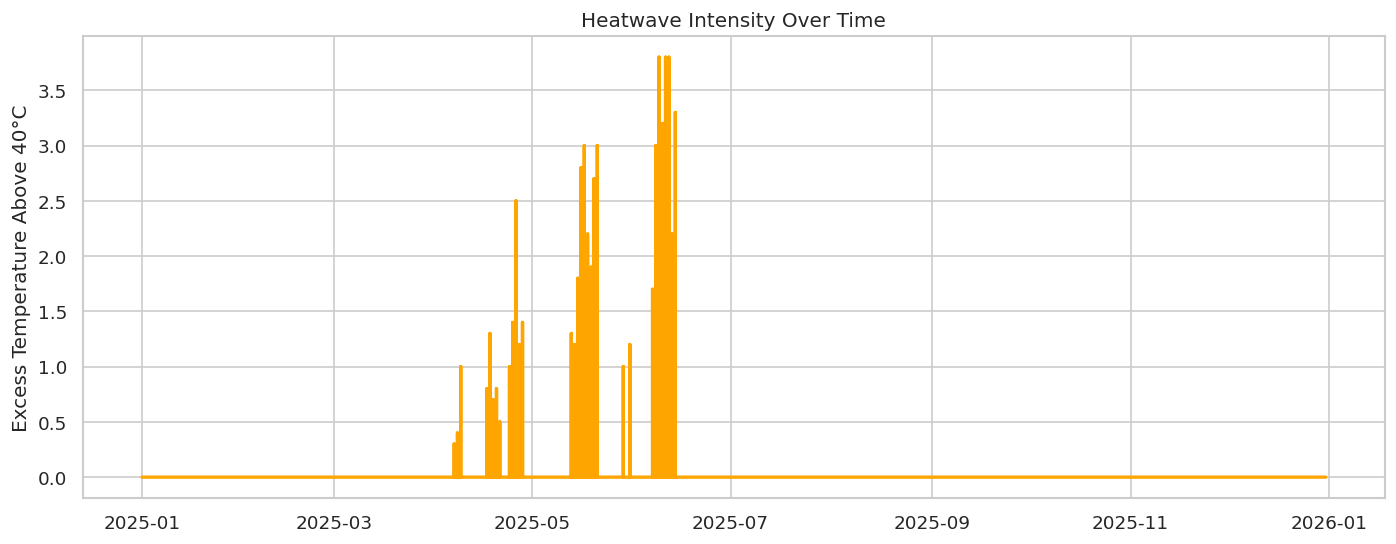

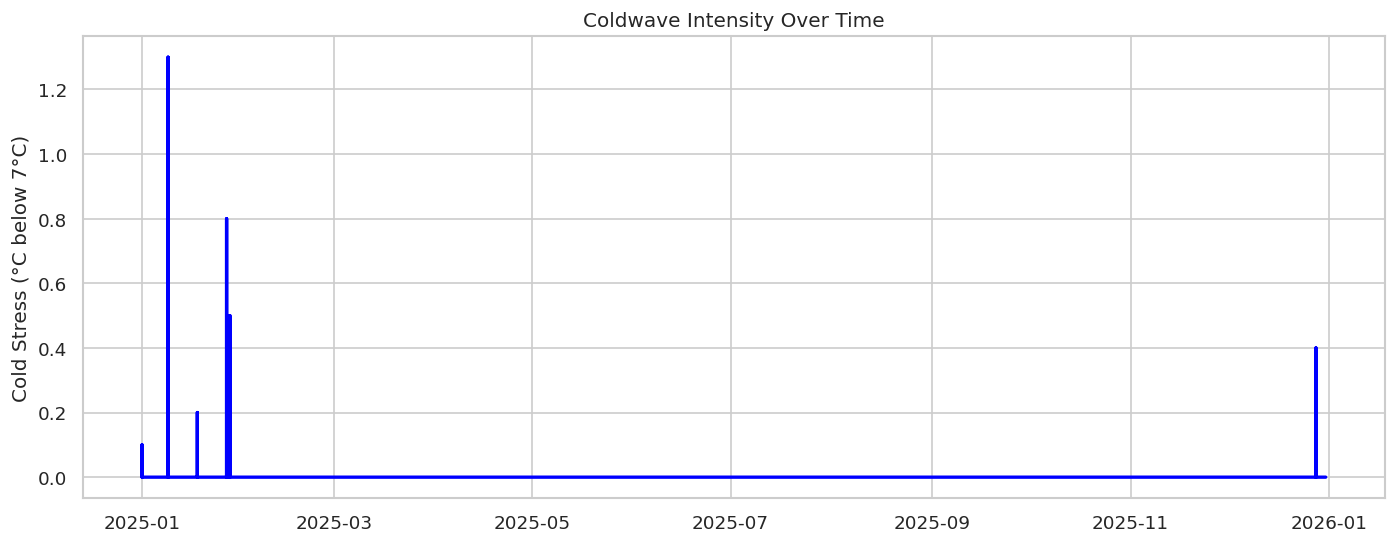

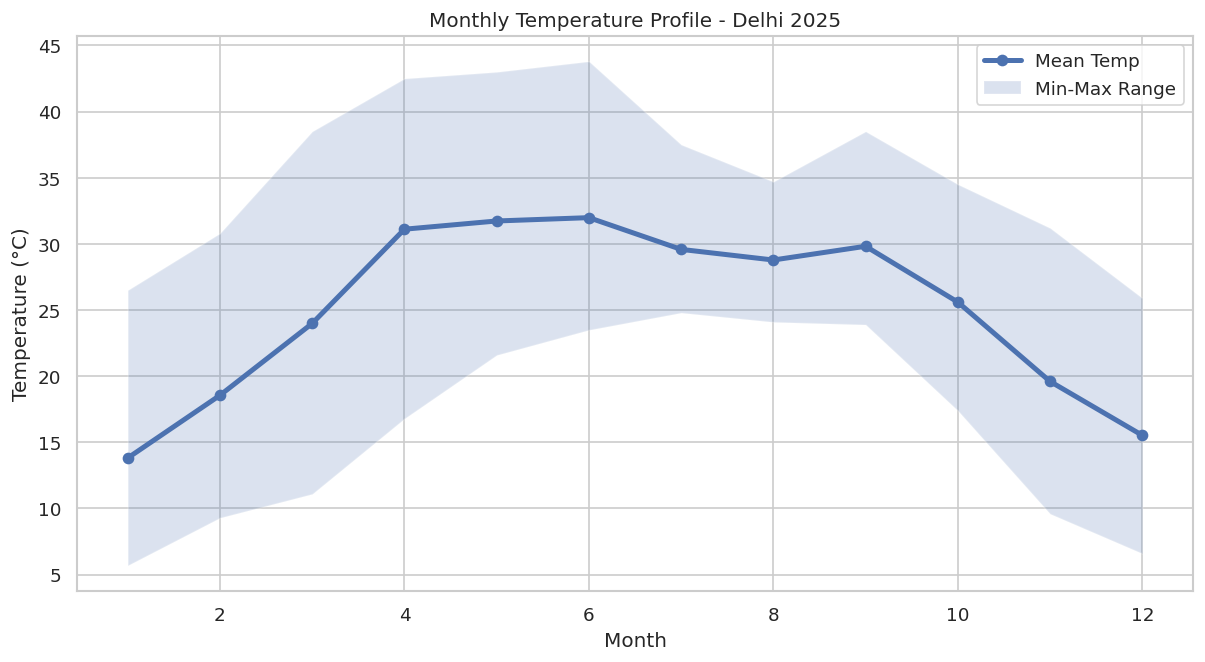

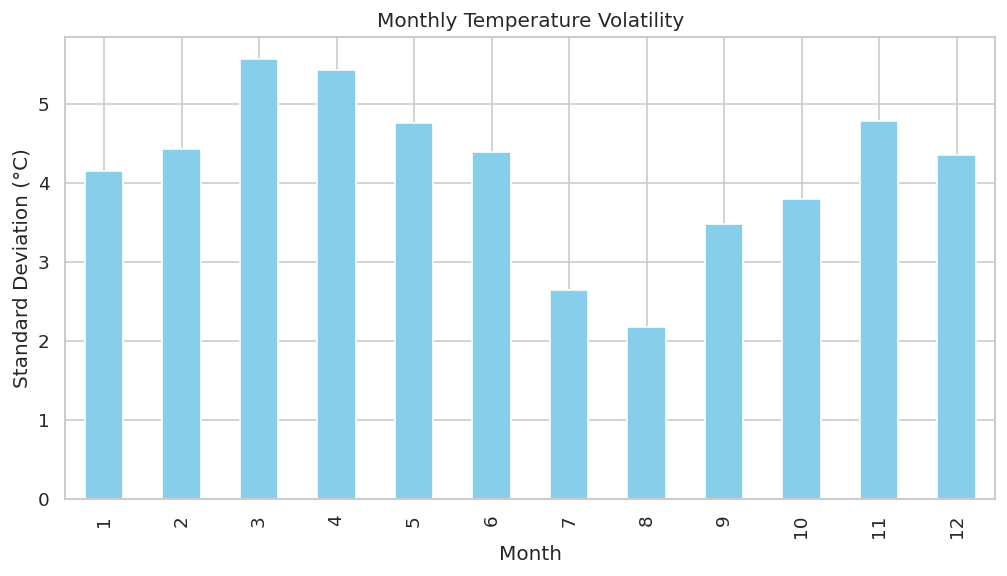

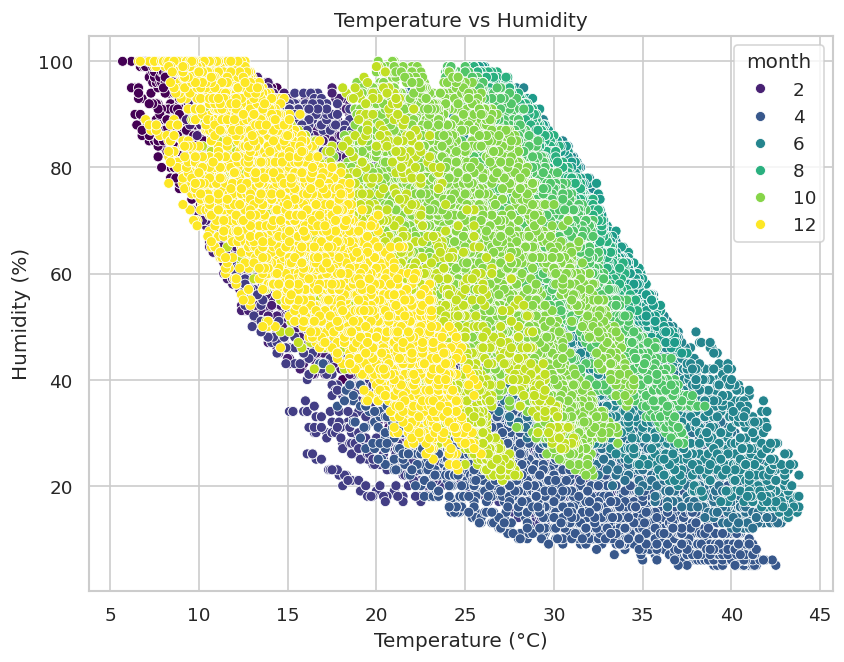

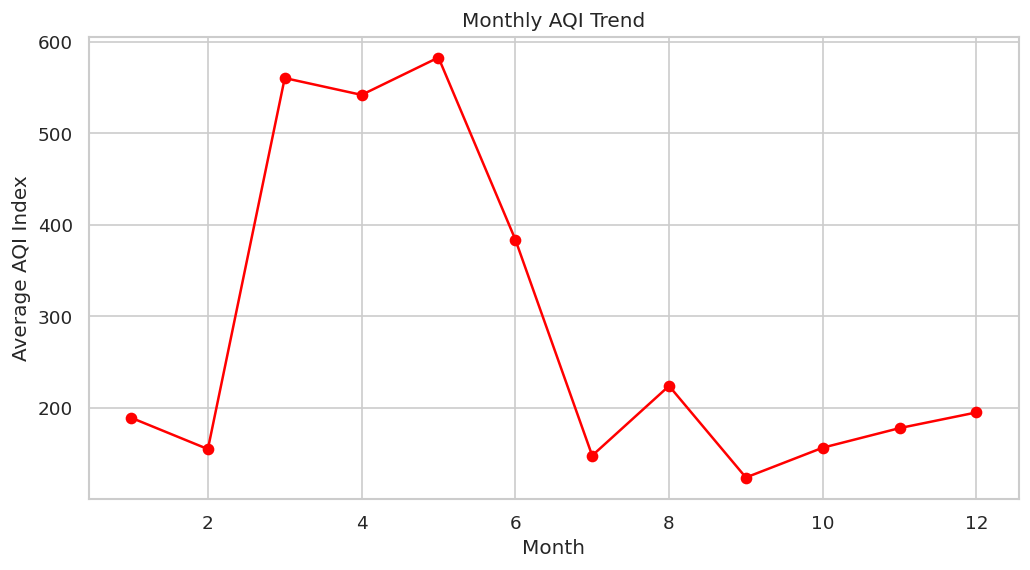

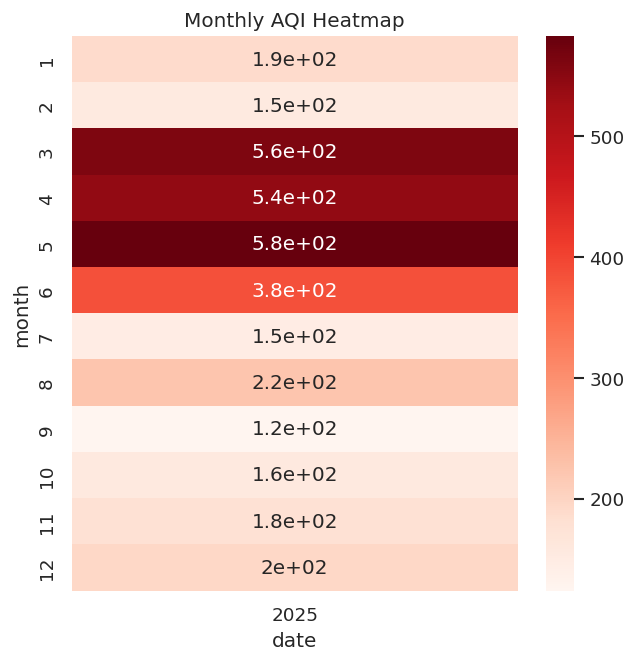

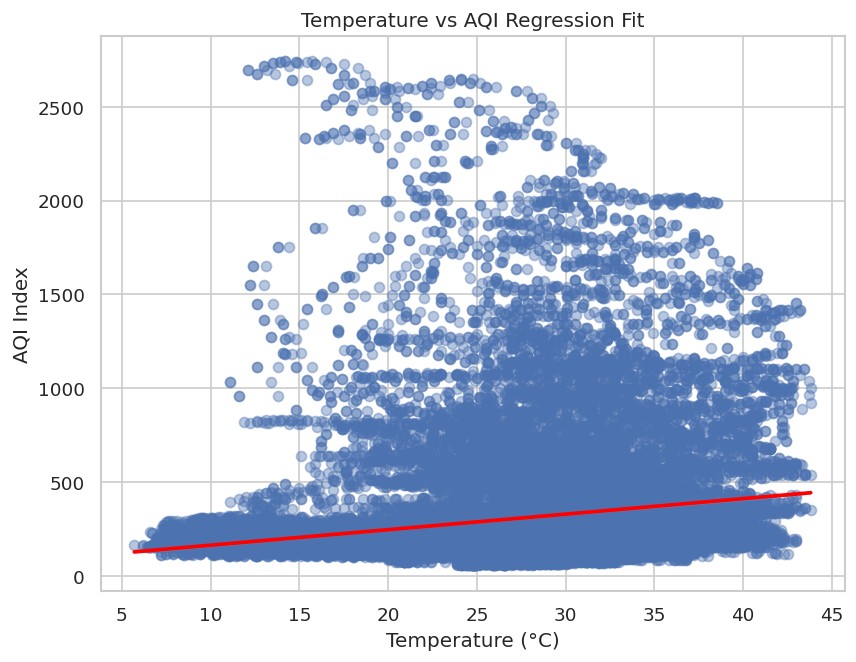

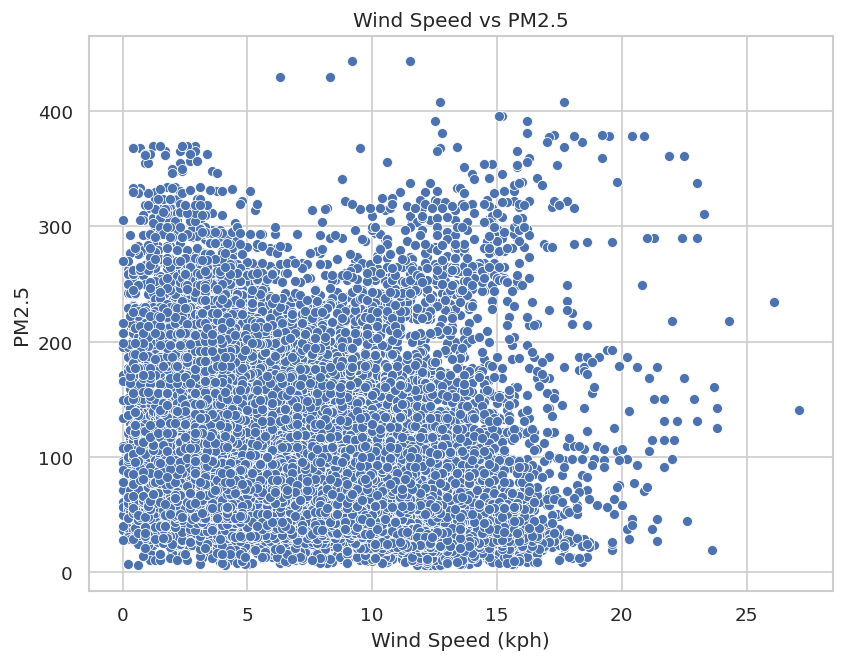

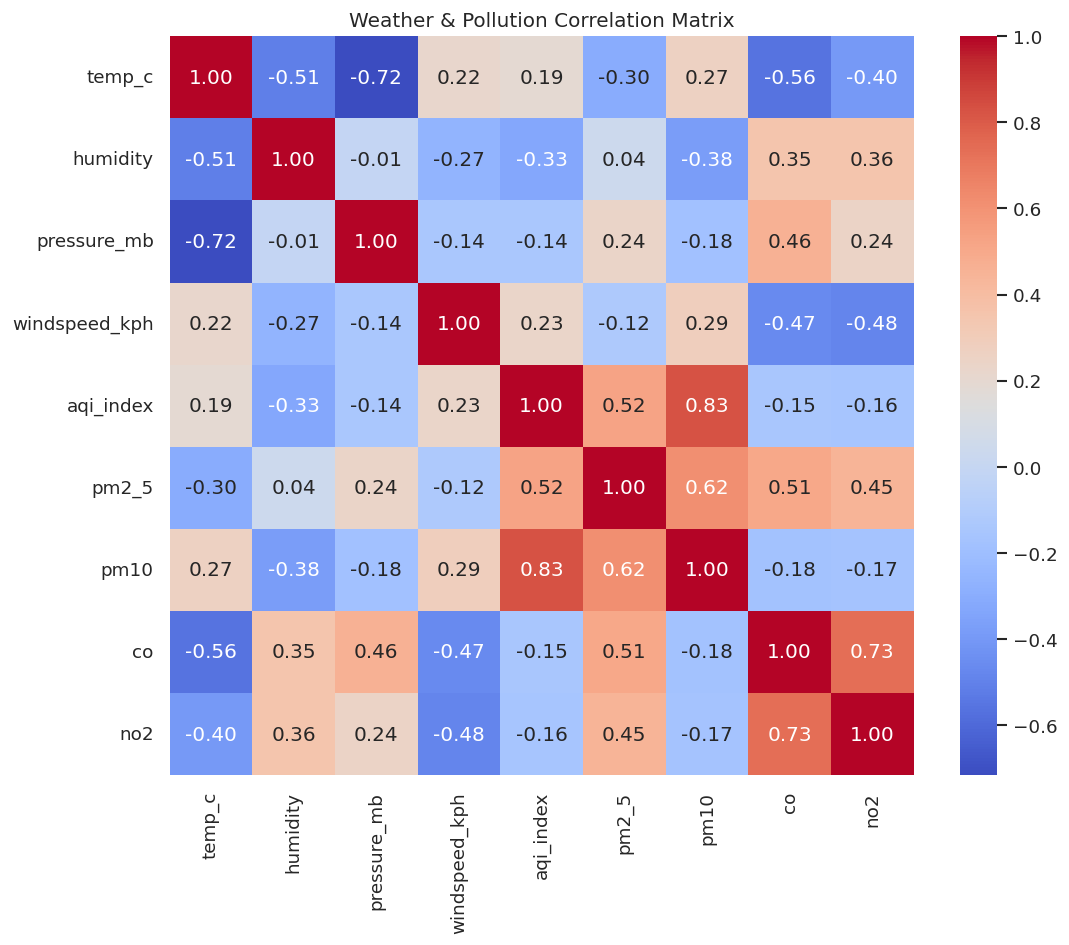

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# -----------------------------
# Assuming 'df' is already loaded with columns:
# 'date', 'temp_c', 'humidity', 'pressure_mb', 'windspeed_kph',
# 'aqi_index', 'pm2_5', 'pm10', 'co', 'no2'
# -----------------------------

# Ensure datetime
df['date'] = pd.to_datetime(df['date'], dayfirst=True)
df['month'] = df['date'].dt.month

# -----------------------------
# 1. Temperature Anomalies (Z-Score > 2)
# -----------------------------
df['temp_z'] = stats.zscore(df['temp_c'])
anomalies = df[abs(df['temp_z']) > 2]

plt.figure(figsize=(14,6))
plt.plot(df['date'], df['temp_c'], alpha=0.6, label='Temperature')
plt.scatter(anomalies['date'], anomalies['temp_c'], color='red', label='Anomalies')
plt.title("Temperature Anomalies (Z-Score > 2)")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.show()

# -----------------------------
# 2. Heatwave & Coldwave Intensity
# -----------------------------
df['heat_intensity'] = np.where(df['temp_c'] > 40, df['temp_c'] - 40, 0)
df['cold_intensity'] = np.where(df['temp_c'] < 7, 7 - df['temp_c'], 0)

plt.figure(figsize=(14,5))
plt.plot(df['date'], df['heat_intensity'], color='orange', linewidth=2)
plt.title("Heatwave Intensity Over Time")
plt.ylabel("Excess Temperature Above 40°C")
plt.show()

plt.figure(figsize=(14,5))
plt.plot(df['date'], df['cold_intensity'], color='blue', linewidth=2)
plt.title("Coldwave Intensity Over Time")
plt.ylabel("Cold Stress (°C below 7°C)")
plt.show()

# -----------------------------
# 3. Monthly Temperature Stats & Volatility
# -----------------------------
monthly_stats = df.groupby('month')['temp_c'].agg(['mean','min','max'])
monthly_volatility = df.groupby('month')['temp_c'].std()

plt.figure(figsize=(12,6))
monthly_stats['mean'].plot(marker='o', linewidth=3, label='Mean Temp')
plt.fill_between(monthly_stats.index, monthly_stats['min'], monthly_stats['max'], alpha=0.2, label='Min-Max Range')
plt.title("Monthly Temperature Profile - Delhi 2025")
plt.xlabel("Month")
plt.ylabel("Temperature (°C)")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(10,5))
monthly_volatility.plot(kind='bar', color='skyblue')
plt.title("Monthly Temperature Volatility")
plt.xlabel("Month")
plt.ylabel("Standard Deviation (°C)")
plt.show()

# -----------------------------
# 4. Temperature vs Humidity
# -----------------------------
plt.figure(figsize=(8,6))
sns.scatterplot(x='temp_c', y='humidity', data=df, hue='month', palette='viridis')
plt.title("Temperature vs Humidity")
plt.xlabel("Temperature (°C)")
plt.ylabel("Humidity (%)")
plt.show()

# -----------------------------
# 5. Monthly AQI Trend & Heatmap
# -----------------------------
monthly_aqi = df.groupby('month')['aqi_index'].mean()

plt.figure(figsize=(10,5))
plt.plot(monthly_aqi.index, monthly_aqi.values, marker='o', color='red')
plt.title("Monthly AQI Trend")
plt.xlabel("Month")
plt.ylabel("Average AQI Index")
plt.grid(True)
plt.show()

# AQI Heatmap by Year
aqi_pivot = df.pivot_table(values='aqi_index', index='month', columns=df['date'].dt.year)
plt.figure(figsize=(6,6))
sns.heatmap(aqi_pivot, annot=True, cmap='Reds')
plt.title("Monthly AQI Heatmap")
plt.show()

# -----------------------------
# 6. Temperature vs AQI Regression
# -----------------------------
plt.figure(figsize=(8,6))
sns.regplot(x='temp_c', y='aqi_index', data=df, scatter_kws={'alpha':0.4}, line_kws={'color':'red'})
plt.title("Temperature vs AQI Regression Fit")
plt.xlabel("Temperature (°C)")
plt.ylabel("AQI Index")
plt.show()

# -----------------------------
# 7. Wind Speed vs PM2.5
# -----------------------------
plt.figure(figsize=(8,6))
sns.scatterplot(x='windspeed_kph', y='pm2_5', data=df)
plt.title("Wind Speed vs PM2.5")
plt.xlabel("Wind Speed (kph)")
plt.ylabel("PM2.5")
plt.show()

# -----------------------------
# 8. Weather & Pollution Correlation Heatmap
# -----------------------------
corr = df[['temp_c','humidity','pressure_mb','windspeed_kph','aqi_index','pm2_5','pm10','co','no2']].corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Weather & Pollution Correlation Matrix")
plt.show()

# **Title**

Delhi Weather & Air Quality Insights Report – 2025

# **Introduction**

This report analyzes Delhi’s weather patterns and air quality trends for the year 2025. Using a comprehensive dataset containing temperature, humidity, pressure, wind speed, and air pollutant measurements (AQI, PM2.5, PM10, CO, NO2), we aim to uncover key insights about seasonal variations, extreme weather events, and pollution dynamics. Visualizations have been created to support the findings in a dashboard-ready format.

# **Programming Language**

Python – chosen for its rich ecosystem of data analysis, visualization, and statistical libraries. Python is widely used in data science, machine learning, and dashboard creation.

# **Data Manipulation & Analysis**

**Pandas (pd) – for:**

Loading datasets (read_csv)

Cleaning and preprocessing data (handling missing values, renaming columns)

Aggregation (groupby) and calculation of statistics (mean, min, max, standard deviation)

Pivot tables and reshaping data

**NumPy (np) – for:**

Numerical computations

Creating arrays and performing calculations like heatwave/coldwave intensity

Conditional operations (np.where)

**SciPy (stats) – for:**

Statistical analysis

Computing Z-scores for detecting temperature anomalies


# **Data Visualization**

**Matplotlib (plt) – for:**

Line plots, bar charts, scatter plots

Heatwave/coldwave intensity visualization

Dashboard-style plotting

**Seaborn (sns) – for:**

Enhanced statistical visualizations

Correlation heatmaps

Scatter plots with regression lines

Color palettes and aesthetic improvements for dashboards

# **Dashboard Creation / Reporting**

While the current code is suitable for static dashboards in Jupyter Notebook or Google Colab, you can extend it to interactive dashboards using:

Plotly – for interactive charts and hover effects

Dash or Streamlit – to build web-based dashboards

# **Temperature Analysis**

Temperature Anomalies

Z-score analysis identified temperature anomalies (days significantly hotter or colder than average).

Extreme heat events (>40°C) predominantly occur in May and June, while extreme cold events (<7°C) occur mainly in January.

These anomalies are critical for public health alerts and planning.

Visualization: Line plot of daily temperature with anomalies highlighted in red.

**Heatwave & Coldwave Intensity**

Heatwave intensity was calculated as the excess temperature above 40°C. Peak intensities occur in late May, reaching extreme values.

Coldwave intensity was calculated as the deficit below 7°C, with maximum stress in early January.

Insights can help municipal authorities and citizens prepare for extreme events.

Visualization: Separate line plots for heatwave and coldwave intensity over time.

### **Monthly Temperature Trends**

Mean monthly temperatures peak in May-June (~40°C) and reach minimum in January (~8–10°C).

Monthly variability (standard deviation) is highest in pre-monsoon months, reflecting unpredictable swings.

Min-max ranges provide insights into day-to-day fluctuations.

Visualization: Line plot with shaded area representing min-max range, bar chart for volatility.

**Temperature vs Humidity**

A moderate negative correlation between temperature and humidity was observed: hotter days tend to be less humid.

Seasonal patterns are visible, with higher humidity during monsoon months (July–September).

Visualization: Scatter plot colored by month.

# **3. Air Quality Analysis**
**Monthly AQI Trends**

Average AQI peaks in November–December, coinciding with winter and stubble burning in neighboring states.

Lower AQI observed in monsoon months, due to rain-driven pollutant washout.

Monitoring these trends is essential for public health advisories.

Visualization: Line plot of monthly AQI.

**AQI Heatmap**

A monthly vs year heatmap highlights high pollution persistence in winter months.

Data indicates recurring air quality challenges during post-monsoon and winter seasons.

Visualization: Heatmap with month on y-axis and year on x-axis (for future multi-year analysis).

**Temperature vs AQI Regression**

Regression analysis shows a positive relationship between temperature and AQI, suggesting that higher temperatures coincide with poorer air quality, possibly due to increased dust and pollutant dispersion.

Visualization: Regression scatter plot.

**Wind Speed vs PM2.5**

Inverse relationship observed: higher wind speeds correlate with lower PM2.5 concentrations.

This indicates that wind acts as a natural air pollutant dispersal mechanism.

Visualization: Scatter plot of wind speed vs PM2.5.

# **Correlation Analysis**

Strong correlations exist among PM2.5, PM10, and NO2, suggesting common sources like traffic and industry.

AQI correlates moderately with temperature and weakly with wind speed and humidity.

Weather parameters (temperature, humidity, wind) show weaker correlations with each other but collectively influence pollution dynamics.

Visualization: Heatmap of correlation matrix.

## **Key Insights and Recommendations**
**Temperature & Weather**

Extreme heat in late spring and early summer necessitates public awareness campaigns.

Coldwaves in winter require provisions for vulnerable populations.

**Air Quality**

High AQI months (Nov–Dec) require temporary emission control measures.

Wind speed and rainfall play critical roles in natural pollutant dispersal.

**Policy & Planning**

Dashboard visualizations allow real-time monitoring of anomalies, helping authorities issue alerts and advisories.

Correlation patterns can inform urban planning, traffic management, and industrial regulation to reduce pollution exposure.

# **6. Conclusion**

The 2025 data reveals a distinct seasonal pattern in Delhi’s weather and air quality:

Peak temperatures in May–June; cold stress in January

High AQI during winter months; mitigated by rainfall and wind

Strong correlation between pollutants suggests targeted interventions could significantly improve air quality

The insights provide actionable information for citizens, health authorities, and policy makers, and are fully visualized in a dashboard-ready format for easy exploration and monitoring.